# 1. Импорты

In [1]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='Set2')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


# 2. Загрузка датасетов

In [2]:
train = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip')
test = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip')

print('Обучающая выборка:', train.shape)
print('Тестовая выборка:', test.shape)

Обучающая выборка: (100000, 9)
Тестовая выборка: (100000, 8)


Были подгружены необходимые библеотеки для работы с линейной алгеброй, таблицами, графиками, а так же sklearn для работы с моделью линейной регрессии.
В следующем блоке загружены .csv файлы для обучающей и тестовой выборки.



# 3. ETL

In [3]:
# создание функции для преобразования данных
def transform(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        df[col] = df[col].str.replace('c-', '', regex=False).astype(int)

    df['DepHour'] = (df['DepTime'] // 100).clip(0, 23).astype(int)
    df['DepMinute'] = (df['DepTime'] % 100).clip(0, 59).astype(int)
    df['DepTimeMinutes'] = df['DepHour'] * 60 + df['DepMinute']
    df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    return df

# применение функции для выборок
train_df = transform(train)
test_df = transform(test)
train_df['target'] = (train_df['dep_delayed_15min'] == 'Y').astype(int)

train_df.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,DepHour,DepMinute,DepTimeMinutes,IsWeekend,target
0,8,21,7,1934,AA,ATL,DFW,732,N,19,34,1174,1,0
1,4,20,3,1548,US,PIT,MCO,834,N,15,48,948,0,0
2,9,2,5,1422,XE,RDU,CLE,416,N,14,22,862,0,0
3,11,25,6,1015,OO,DEN,MEM,872,N,10,15,615,1,0
4,10,7,6,1828,WN,MDW,OMA,423,Y,18,28,1108,1,1


Тут происходит предобработка данных, функция `transform` приводит календарные признаки к числовому виду, выделяет час и минуту вылета, считает время в минутах и добавляет признак выходного дня. После обработки создается бинарная целевая переменная: `1` означает задержку рейса, `0` - отсутствие задержки.


# 4. EDA

Доля задержанных рейсов: 0.1904


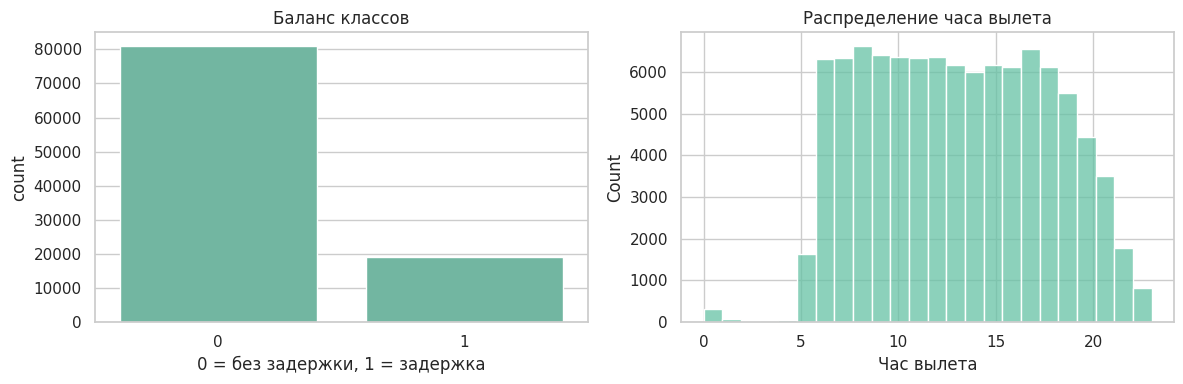

In [4]:
print('Доля задержанных рейсов:', round(train_df['target'].mean(), 4))

# создание графика с балансом классом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x='target', ax=axes[0])
axes[0].set_title('Баланс классов')
axes[0].set_xlabel('0 = без задержки, 1 = задержка')
# график по распределению часов
sns.histplot(data=train_df, x='DepHour', bins=24, ax=axes[1])
axes[1].set_title('Распределение часа вылета')
axes[1].set_xlabel('Час вылета')

plt.tight_layout()
plt.show()

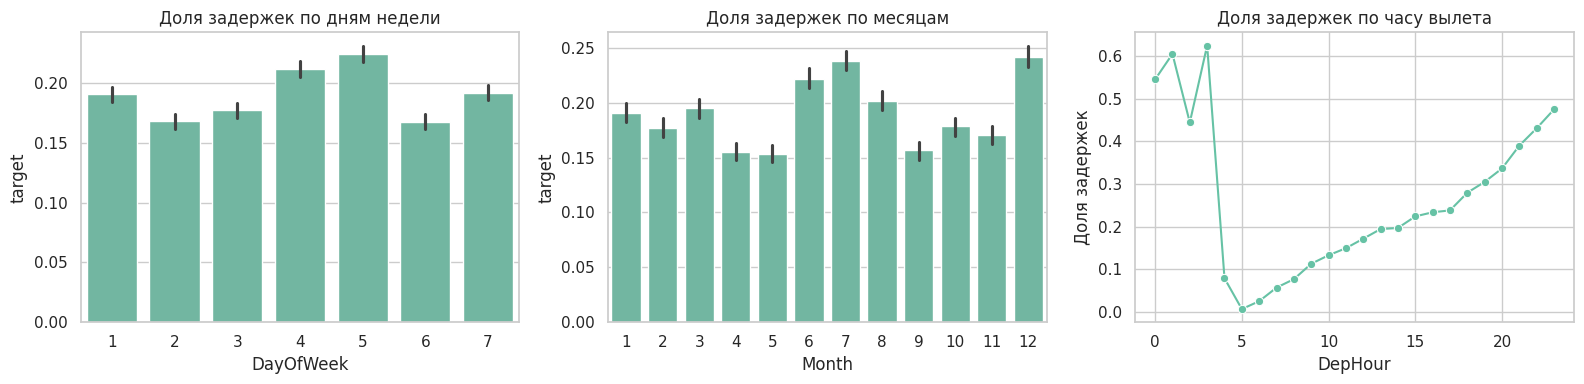

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=train_df, x='DayOfWeek', y='target', estimator=np.mean, ax=axes[0])
axes[0].set_title('Доля задержек по дням недели')

sns.barplot(data=train_df, x='Month', y='target', estimator=np.mean, ax=axes[1])
axes[1].set_title('Доля задержек по месяцам')

sns.lineplot(data=train_df.groupby('DepHour')['target'].mean().reset_index(), x='DepHour', y='target', marker='o', ax=axes[2])
axes[2].set_title('Доля задержек по часу вылета')
axes[2].set_ylabel('Доля задержек')

plt.tight_layout()
plt.show()

def build_features(train_df, test_df, num_features, cat_features):
    ohe = make_ohe()
    ohe.fit(pd.concat([train_df[cat_features], test_df[cat_features]], axis=0))

    X = hstack([
        train_df[num_features].astype(float).values,
        ohe.transform(train_df[cat_features]),
    ]).tocsr()

    X_test = hstack([
        test_df[num_features].astype(float).values,
        ohe.transform(test_df[cat_features]),
    ]).tocsr()

    return X, X_test, ohe


y = train_df['target'].values

В этом разделе проводится разведочный анализ данных. Сначала оценивается доля задержанных рейсов в обучающей выборке, чтобы понять распределение целевой переменной. Затем строятся графики, показывающие баланс классов и распределение рейсов по времени вылета. Также анализируется, как частота задержек меняется в зависимости от дня недели, месяца и часа вылета. Это помогает выявить возможные закономерности в данных перед обучением модели.

# 5. Подготовка матрицы признаков

Почему One-Hot Encoding: логистическая регрессия не умеет напрямую работать со строковыми категориями. One-hot превращает авиакомпании и аэропорты в числовые бинарные признаки, а разреженная матрица экономит память.

In [6]:
# создаем One-Hot Encoder для преобразования категориальных признаков в числа
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

# подготовка признаков
def build_features(train_df, test_df, num_features, cat_features):
    ohe = make_ohe()
    ohe.fit(pd.concat([train_df[cat_features], test_df[cat_features]], axis=0))

    X = hstack([
        train_df[num_features].astype(float).values,
        ohe.transform(train_df[cat_features]),
    ]).tocsr()

    X_test = hstack([
        test_df[num_features].astype(float).values,
        ohe.transform(test_df[cat_features]),
    ]).tocsr()

    return X, X_test, ohe


y = train_df['target'].values

Тут выполняется подготовка признаков для обучения модели. Числовые признаки используются напрямую, а категориальные признаки, такие как авиакомпания, аэропорт вылета и аэропорт назначения, преобразуются в числовой формат с помощью One-Hot Encoding. После этого числовые и закодированные категориальные признаки объединяются в единую матрицу признаков для обучающей и тестовой выборки. Также отдельно выделяется целевая переменная `y`, которая показывает, был ли рейс задержан более чем на 15 минут.

# 6. Модель логистической регрессии

In [7]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

X_base, X_test_base, ohe_base = build_features(train_df, test_df, NUM_FEATURES, CAT_FEATURES)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)
#создание модели
baseline_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
baseline_model.fit(X_tr, y_tr)

# подсчёт ROC AUC
baseline_val_pred = baseline_model.predict_proba(X_val)[:, 1]
baseline_auc = roc_auc_score(y_val, baseline_val_pred)
print('ROC AUC логистической регрессии:', round(baseline_auc, 5))

ROC AUC логистической регрессии: 0.70138


Здесь обучается базовая модель логистической регрессии. Сначала задаются числовые и категориальные признаки, после чего с помощью ранее подготовленной функции формируются матрицы признаков для обучающей и тестовой выборки. Затем обучающая выборка делится на тренировочную и валидационную части с сохранением пропорции классов. На тренировочных данных обучается модель логистической регрессии, а на валидационной выборке оценивается ее качество с помощью метрики ROC AUC. Полученное значение используется как базовый результат для сравнения с более сложными моделями.

# 7. Модель CatBoost

In [8]:
from catboost import CatBoostClassifier

# признаки для CatBoost
CATBOOST_FEATURES = NUM_FEATURES + CAT_FEATURES
CATBOOST_CAT_FEATURES = CAT_FEATURES

train_cb = train_df[CATBOOST_FEATURES].copy()
test_cb = test_df[CATBOOST_FEATURES].copy()

for col in CATBOOST_CAT_FEATURES:
    train_cb[col] = train_cb[col].astype(str)
    test_cb[col] = test_cb[col].astype(str)

X_tr_cb, X_val_cb, y_tr_cb, y_val_cb = train_test_split(
    train_cb, y, test_size=0.2, random_state=42, stratify=y

)
# создание модели CatBoostClassifier
catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=3,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)
# обучение модели
catboost_model.fit(
    X_tr_cb,
    y_tr_cb,
    cat_features=CAT_FEATURES,
    eval_set=(X_val_cb, y_val_cb),
    use_best_model=True,
)

catboost_val_pred = catboost_model.predict_proba(X_val_cb)[:, 1]
catboost_auc = roc_auc_score(y_val_cb, catboost_val_pred)
# сравниваем результат CatBoost с логистической регрессией.
print('ROC AUC CatBoost:', round(catboost_auc, 5))
print('Прирост относительно логистической регрессии:', round(catboost_auc - baseline_auc, 5))

ROC AUC CatBoost: 0.72483
Прирост относительно логистической регрессии: 0.02345


В этом разделе обучается более сложная модель CatBoostClassifier. Для нее используются те же числовые и категориальные признаки, но категориальные признаки передаются модели напрямую, так как CatBoost умеет работать с ними без One-Hot. Данные делятся на тренировочную и валидационную части с сохранением баланса классов. Затем модель обучается на тренировочной выборке и оценивается на валидационной с помощью метрики ROC AUC. В конце результат CatBoost сравнивается с базовой логистической регрессией, чтобы понять, дала ли более сложная модель улучшение качества.

# 8. Создание submittion.csv

In [9]:
test_pred = catboost_model.predict_proba(test_cb)[:, 1]

sample_submission = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip')

submission = sample_submission.copy()
submission['dep_delayed_15min'] = test_pred

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print('Сохранено:', submission_path)
print('Строк:', len(submission), '| минимум:', submission['dep_delayed_15min'].min(), '| максимум:', submission['dep_delayed_15min'].max())
submission.head()

Сохранено: submission.csv
Строк: 100000 | минимум: 0.014460648043990346 | максимум: 0.8728090353588476


,id,dep_delayed_15min
0,0,0.050761
1,1,0.062678
2,2,0.043977
3,3,0.263881
4,4,0.233300


## Вывод

В ходе работы удалось подготовить данные для обучения модели: были преобразованы признаки даты и времени, создана целевая переменная, а также выполнен первичный анализ данных. Хорошо сработала базовая модель логистической регрессии, так как она достаточно проста в настройке и позволила получить начальный результат, с которым можно сравнивать более сложные модели.

Основные сложности возникли при работе с моделью CatBoost. Было не сразу понятно, как правильно передавать категориальные признаки, какие параметры модели выбрать и как настроить обучение, чтобы модель корректно работала с данными. В отличие от логистической регрессии, CatBoost имеет больше гиперпараметров, поэтому его настройка требует лучшего понимания работы модели.

Возможные улучшения решения могут включать подбор параметров CatBoost: количество итераций, глубины и скорости обучения. Также можно добавить новые признаки, связанные с маршрутом, аэропортами, расстоянием и временем вылета, а затем проверить, улучшают ли они качество модели. Кроме того, можно использовать кросс-валидацию для более надежной оценки качества и сравнить CatBoost с другими алгоритмами машинного обучения.
